## Pipeline

1.  **DATA OVERVIEW** - Load and merge all 3 datasets (touchpoints, user profiles,
    campaign spend) and compute baseline conversion metrics.
    
2.  **BOT DETECTION** - Identify and remove fake bot users using 3 behavioral anomaly
    rules — speed, click fraud, and campaign spam — before any
    attribution modeling begins.

    
3.  **JOURNEY RECONSTRUCTION** - Reconstruct each user's chronological channel sequence and tag journeys as Converted or Null (dropout).

   
4.  **TRANSITION MATRIX** - Build a per-brand probability matrix showing how likely
customers are to move from one channel state to another.


5.  **REMOVAL EFFECT** - Remove each channel one at a time and measure the drop in
    conversion rate — the bigger the drop, the more credit
    that channel deserves.

    
6.  **CPA CALCULATION** - Compute True Cost Per Acquisition using Markov attribution
    credits instead of Last-Click to get accurate channel costs.


7.  **ROI CALCULATION** - Calculate Return on Investment per channel per brand using
    true attributed conversions against actual spend.


8.  **BUDGET PHASE REALLOCATION** - Optimally distribute ₹10 Crore per brand based on CPA
    efficiency with a 60% diminishing returns cap per channel.


9. **LAST-CLICK ATTRIBUTION** - Calculate Last-Click baseline to compare against Markov
     and prove where credit was being misassigned.

    
10. **VISUALIZATIONS** - Generate attribution heatmaps, CPA heatmap, and old vs
     new budget comparison charts for the CMO deck.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1=pd.read_csv('campaign_spend.csv')
df2=pd.read_csv('touchpoints.csv')
df3=pd.read_csv('user_profiles.csv')

#  -------------------------------- DATA OVERVIEW --------------------------------------

## 1. How many purchases actually happened?

In [3]:
df2['Event_Type'].value_counts()
# 5498 purchases

Event_Type
Impression     439694
Click          118191
Purchase         5498
Add-to-Cart      3127
Name: count, dtype: int64

In [4]:
# 5498 purchases total

## 2. How many users per brand

In [5]:
import duckdb

result = duckdb.sql("""
        SELECT *
        FROM df2
        INNER JOIN df3
            ON df2.User_ID = df3.User_ID
        INNER JOIN df1
            ON df1.Campaign_ID = df2.Campaign_ID
            """).df()

In [6]:
result.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,User_ID_1,Segment,Trend_Affinity,Geography,Campaign_ID_1,Brand_ID,Channel_1,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated
0,U_B06_04495,1/3/2026 20:46,CMP_B06_INS_122,Instagram,Impression,U_B06_04495,Budget Parent,Sustainable Packaging,Tier 2,CMP_B06_INS_122,B06,Instagram,CPM,345.40,727584.70
1,U_B06_04496,1/1/2026 21:01,CMP_B06_GOO_837,Google Search,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_GOO_837,B06,Google Search,CPC,24.71,39418418.56
2,U_B06_04496,1/2/2026 21:01,CMP_B06_GOO_837,Google Search,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_GOO_837,B06,Google Search,CPC,24.71,39418418.56
3,U_B06_04496,1/4/2026 23:01,CMP_B06_YOU_876,YouTube,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_YOU_876,B06,YouTube,CPM,303.04,31425004.26
4,U_B06_04496,1/7/2026 14:01,CMP_B06_GOO_837,Google Search,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_GOO_837,B06,Google Search,CPC,24.71,39418418.56


In [7]:
percentage= (result.groupby('Brand_ID').count()['User_ID'] 
             / result.groupby('Brand_ID').count()['User_ID'].sum())

In [8]:
print(percentage*100.0)

Brand_ID
B01    10.269722
B02    10.061605
B03     9.709096
B04     9.748283
B05    10.003354
B06    10.190288
B07    10.208293
B08     9.734691
B09    10.144922
B10     9.929745
Name: User_ID, dtype: float64


In [9]:
# users percentage per brand

## 3. Journey length

In [10]:
import duckdb

result1 = duckdb.sql("""
        SELECT User_ID,Channel,Event_Type,Timestamp
        FROM df2
        ORDER BY User_ID, Timestamp
            """).df()

In [11]:
result1

,User_ID,Channel,Event_Type,Timestamp
0,U_B01_00000,Influencer Blog,Impression,1/1/2026 19:27
1,U_B01_00001,Google Search,Impression,1/1/2026 20:37
2,U_B01_00001,Google Search,Click,1/1/2026 20:38
3,U_B01_00001,Marketplace,Impression,1/4/2026 15:37
4,U_B01_00001,Instagram,Impression,1/6/2026 8:37
...,...,...,...,...
566505,U_B10_09998,YouTube,Impression,1/6/2026 9:01
566506,U_B10_09998,Instagram,Impression,1/8/2026 1:01
566507,U_B10_09999,Instagram,Impression,1/1/2026 19:50
566508,U_B10_09999,YouTube,Impression,1/3/2026 17:50


In [12]:
df2.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type
0,U_B01_00000,1/1/2026 19:27,CMP_B01_INF_899,Influencer Blog,Impression
1,U_B01_00001,1/1/2026 20:37,CMP_B01_GOO_434,Google Search,Impression
2,U_B01_00001,1/1/2026 20:38,CMP_B01_GOO_434,Google Search,Click
3,U_B01_00001,1/4/2026 15:37,CMP_B01_MAR_127,Marketplace,Impression
4,U_B01_00001,1/6/2026 8:37,CMP_B01_INS_285,Instagram,Impression


In [13]:
import duckdb

result1 = duckdb.sql("""
        SELECT User_ID,COUNT(*) as journey_length,

            SUM(CASE WHEN Event_Type='Purchase' THEN 1 ELSE 0 END) as converted
            
        FROM df2
        GROUP BY User_ID
        ORDER BY journey_length DESC
            """).df()

In [14]:
result1.describe()

,journey_length,converted
count,100000.000000,100000.000000
mean,5.665100,0.054980
std,13.754565,0.227942
min,1.000000,0.000000
25%,2.000000,0.000000
50%,4.000000,0.000000
75%,5.000000,0.000000
max,140.000000,1.000000


In [15]:
result1['journey_length'].value_counts().head(10)

journey_length
4     15410
3     15175
5     15141
2     15086
6     15078
1     14759
7      5400
8      1582
9       341
10       63
Name: count, dtype: int64

In [16]:
result1['converted'].value_counts()

converted
0.0    94502
1.0     5498
Name: count, dtype: int64

In [17]:
# result1 shows the Journey Length

## 4. What % of users actually converted (reached Purchase)

In [18]:
result.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,User_ID_1,Segment,Trend_Affinity,Geography,Campaign_ID_1,Brand_ID,Channel_1,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated
0,U_B06_04495,1/3/2026 20:46,CMP_B06_INS_122,Instagram,Impression,U_B06_04495,Budget Parent,Sustainable Packaging,Tier 2,CMP_B06_INS_122,B06,Instagram,CPM,345.40,727584.70
1,U_B06_04496,1/1/2026 21:01,CMP_B06_GOO_837,Google Search,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_GOO_837,B06,Google Search,CPC,24.71,39418418.56
2,U_B06_04496,1/2/2026 21:01,CMP_B06_GOO_837,Google Search,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_GOO_837,B06,Google Search,CPC,24.71,39418418.56
3,U_B06_04496,1/4/2026 23:01,CMP_B06_YOU_876,YouTube,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_YOU_876,B06,YouTube,CPM,303.04,31425004.26
4,U_B06_04496,1/7/2026 14:01,CMP_B06_GOO_837,Google Search,Impression,U_B06_04496,Budget Parent,Value-Pack,Tier 3,CMP_B06_GOO_837,B06,Google Search,CPC,24.71,39418418.56


In [19]:
total_users = result['User_ID'].nunique()
converted_users = result[result['Event_Type']=='Purchase']['User_ID'].unique()

In [20]:
conversion_rate = len(converted_users) * 100.0/total_users
conversion_rate

5.498

In [21]:
# 5.498% users converted

## Final Findings I found

1. Total 5498 purchases happened

2. % of Users per brand is -
   * B01  ->  10.269722 %
   * B02  -> 10.061605 %
   * B03  ->   9.709096 %
   * B04  ->   9.748283 %
   * B05  ->  10.003354 %
   * B06  ->  10.190288 %
   * B07  ->  10.208293 %
   * B08  ->   9.734691 %
   * B09  ->  10.144922 %
   * B10  ->   9.929745 %

3. frequency of Event_type happened per user

    more event_type frequency per person means it could be a bot

    journey_length
    * 4  ->    15410
    * 3  ->   15175
    * 5  ->   15141
    * 2  ->   15086
    * 6  ->  15078
    * 1  ->   14759
    * 7  ->    5400
    * 8  ->     1582
    * 9  ->     341
    * 10 ->      63

6. % of users actually converted is 5.498%

#  -------------------------------- BOT DETECTION --------------------------------------

## 1. Speed Check

In [22]:
result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 566510 entries, 0 to 566509
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   User_ID                 566510 non-null  object 
 1   Timestamp               566510 non-null  object 
 2   Campaign_ID             566510 non-null  object 
 3   Channel                 566510 non-null  object 
 4   Event_Type              566510 non-null  object 
 5   User_ID_1               566510 non-null  object 
 6   Segment                 566510 non-null  object 
 7   Trend_Affinity          566510 non-null  object 
 8   Geography               566510 non-null  object 
 9   Campaign_ID_1           566510 non-null  object 
 10  Brand_ID                566510 non-null  object 
 11  Channel_1               566510 non-null  object 
 12  Pricing_Model           566510 non-null  object 
 13  Cost_Rate_INR           566510 non-null  float64
 14  Total_Budget_Allocat

In [23]:
result['Timestamp']=pd.to_datetime(result['Timestamp'])

In [24]:
result=result.sort_values(['User_ID','Timestamp'])

In [25]:
result.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,User_ID_1,Segment,Trend_Affinity,Geography,Campaign_ID_1,Brand_ID,Channel_1,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated
102400,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,U_B01_00000,Fitness Enthusiast,Sustainable Packaging,Tier 1,CMP_B01_INF_899,B01,Influencer Blog,CPM,329.34,14499430.43
102401,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25
102402,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25
102403,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_MAR_127,B01,Marketplace,CPC,37.54,37182759.79
102404,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_INS_285,B01,Instagram,CPM,391.98,613144.27


In [26]:
result['time_diff']=result.groupby('User_ID')['Timestamp'].diff()

In [27]:
result.head()

,User_ID,Timestamp,Campaign_ID,Channel,Event_Type,User_ID_1,Segment,Trend_Affinity,Geography,Campaign_ID_1,Brand_ID,Channel_1,Pricing_Model,Cost_Rate_INR,Total_Budget_Allocated,time_diff
102400,U_B01_00000,2026-01-01 19:27:00,CMP_B01_INF_899,Influencer Blog,Impression,U_B01_00000,Fitness Enthusiast,Sustainable Packaging,Tier 1,CMP_B01_INF_899,B01,Influencer Blog,CPM,329.34,14499430.43,NaT
102401,U_B01_00001,2026-01-01 20:37:00,CMP_B01_GOO_434,Google Search,Impression,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25,NaT
102402,U_B01_00001,2026-01-01 20:38:00,CMP_B01_GOO_434,Google Search,Click,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_GOO_434,B01,Google Search,CPC,23.41,27896859.25,0 days 00:01:00
102403,U_B01_00001,2026-01-04 15:37:00,CMP_B01_MAR_127,Marketplace,Impression,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_MAR_127,B01,Marketplace,CPC,37.54,37182759.79,2 days 18:59:00
102404,U_B01_00001,2026-01-06 08:37:00,CMP_B01_INS_285,Instagram,Impression,U_B01_00001,Fitness Enthusiast,Vegan,Tier 1,CMP_B01_INS_285,B01,Instagram,CPM,391.98,613144.27,1 days 17:00:00


In [28]:
fast_gaps = result[result['time_diff'].dt.total_seconds() < 5].groupby('User_ID').size()
rule1_bots = fast_gaps[fast_gaps >= 3].index

In [29]:
rule1_bots

Index(['U_B01_00024', 'U_B01_00105', 'U_B01_00114', 'U_B01_00173',
       'U_B01_00174', 'U_B01_00205', 'U_B01_00424', 'U_B01_00445',
       'U_B01_00473', 'U_B01_00474',
       ...
       'U_B10_09628', 'U_B10_09691', 'U_B10_09698', 'U_B10_09766',
       'U_B10_09767', 'U_B10_09846', 'U_B10_09851', 'U_B10_09874',
       'U_B10_09910', 'U_B10_09939'],
      dtype='object', name='User_ID', length=1965)

## 2. Impression to Click Ratio

In [30]:
click_rate_df = pd.DataFrame({
    'clicks': result[result['Event_Type']=='Click'].groupby('User_ID').size(),
    'impressions': result[result['Event_Type']=='Impression'].groupby('User_ID').size()
}).fillna(0)

In [31]:
click_rate_df

,clicks,impressions
User_ID,,
U_B01_00000,0.0,1
U_B01_00001,1.0,4
U_B01_00002,1.0,5
U_B01_00003,0.0,2
U_B01_00004,0.0,4
...,...,...
U_B10_09995,0.0,1
U_B10_09996,0.0,1
U_B10_09997,0.0,1


In [32]:
click_rate_df['click_rate'] = click_rate_df['clicks'] / click_rate_df['impressions'].replace(0, np.nan)

In [33]:
click_rate_df

,clicks,impressions,click_rate
User_ID,,,
U_B01_00000,0.0,1,0.00
U_B01_00001,1.0,4,0.25
U_B01_00002,1.0,5,0.20
U_B01_00003,0.0,2,0.00
U_B01_00004,0.0,4,0.00
...,...,...,...
U_B10_09995,0.0,1,0.00
U_B10_09996,0.0,1,0.00
U_B10_09997,0.0,1,0.00


In [34]:
rule2_bots = click_rate_df[click_rate_df['click_rate'] > 0.5].index

In [35]:
rule2_bots

Index(['U_B01_00024', 'U_B01_00105', 'U_B01_00111', 'U_B01_00114',
       'U_B01_00173', 'U_B01_00174', 'U_B01_00205', 'U_B01_00218',
       'U_B01_00229', 'U_B01_00278',
       ...
       'U_B10_09851', 'U_B10_09858', 'U_B10_09874', 'U_B10_09886',
       'U_B10_09910', 'U_B10_09925', 'U_B10_09936', 'U_B10_09939',
       'U_B10_09940', 'U_B10_09959'],
      dtype='object', name='User_ID', length=3151)

## 3. Repition on Same Campaign 

In [36]:
counts = result.groupby(['User_ID','Campaign_ID']).size().reset_index(name='count')

In [37]:
counts=counts.set_index('User_ID')

In [38]:
rule3_bots = counts[counts['count'] > 15].index.unique()

In [39]:
rule3_bots

Index(['U_B01_00024', 'U_B01_00105', 'U_B01_00114', 'U_B01_00173',
       'U_B01_00174', 'U_B01_00205', 'U_B01_00424', 'U_B01_00445',
       'U_B01_00473', 'U_B01_00474',
       ...
       'U_B10_09628', 'U_B10_09691', 'U_B10_09698', 'U_B10_09766',
       'U_B10_09767', 'U_B10_09846', 'U_B10_09851', 'U_B10_09874',
       'U_B10_09910', 'U_B10_09939'],
      dtype='object', name='User_ID', length=1942)

## 4. KILLING THE BOTS 

In [40]:
all_bots = set(rule1_bots) | set(rule2_bots) | set(rule3_bots) # Union

clean_df = result[~result['User_ID'].isin(all_bots)]

print(f"Total users: {result['User_ID'].nunique()}")
print(f"Rule 1 bots: {len(rule1_bots)}")
print(f"Rule 2 bots: {len(rule2_bots)}")
print(f"Rule 3 bots: {len(rule3_bots)}") 
print(f"Total unique bots: {len(all_bots)}")
print(f"Clean users remaining: {clean_df['User_ID'].nunique()}")

Total users: 100000
Rule 1 bots: 1965
Rule 2 bots: 3151
Rule 3 bots: 1942
Total unique bots: 3155
Clean users remaining: 96845


## Final Findings I found

1. Total Users before cleaning : 100000
2. Total bots found : 3155
3. % of total traffic of bots is 3.155 %
4. * Before bot removal: 5.498% conversion rate
   * After bot removal:  5.628% conversion rate
   * Bots were suppressing true conversion by ~2.4%

In [41]:
# 1. which channels has highest bot concentration
bot_data=result[result['User_ID'].isin(all_bots)]
percent_bot_channel=((bot_data.groupby('Channel')['User_ID'].count() * 100.0)
                     / bot_data.groupby('Channel')['User_ID'].count().sum())
percent_bot_channel

Channel
Google Search      20.071373
Influencer Blog    19.835995
Instagram          20.168054
Marketplace        19.999494
YouTube            19.925084
Name: User_ID, dtype: float64

In [42]:
# 2. which brands has highest bot concentration
percent_bot_brand=((bot_data.groupby('Brand_ID')['User_ID'].count() * 100.0)
                     / bot_data.groupby('Brand_ID')['User_ID'].count().sum())
percent_bot_brand

Brand_ID
B01    10.668421
B02     9.814988
B03     9.134165
B04     9.331072
B05    10.436081
B06    10.596037
B07    10.131862
B08     9.467237
B09    10.446205
B10     9.973931
Name: User_ID, dtype: float64

In [43]:
# 3. Conversion rate after cleaning
clean_converted = clean_df[clean_df['Event_Type']=='Purchase']['User_ID'].nunique()
clean_total = clean_df['User_ID'].nunique()
clean_conversion_rate = clean_converted / clean_total * 100
print(f"Conversion rate after cleaning: {clean_conversion_rate:.3f}%")

Conversion rate after cleaning: 5.628%


In [44]:
# 4.Total purchases after cleaning
purchases_clean = clean_df[clean_df['Event_Type']=='Purchase'].shape[0]
print(f"Total purchases (clean): {purchases_clean}")

Total purchases (clean): 5450


In [45]:
# 5. Brand distribution after cleaning
brand_dist_clean = (clean_df.groupby('Brand_ID')['User_ID'].count() * 100.0
                   / clean_df.groupby('Brand_ID')['User_ID'].count().sum())
print(brand_dist_clean)

Brand_ID
B01    10.056240
B02    10.193655
B03    10.016940
B04     9.971677
B05     9.771652
B06     9.973032
B07    10.249217
B08     9.877898
B09     9.983602
B10     9.906086
Name: User_ID, dtype: float64


In [46]:
# 6. Journey length after cleaning
journey_clean = clean_df.groupby('User_ID').size()
print(journey_clean.value_counts().head(10))

4     15353
6     15033
3     15023
5     14999
1     14759
2     14332
7      5385
8      1566
9       327
10       58
Name: count, dtype: int64


#  -------------------------- JOURNEY RECONSTRUCTION ------------------------------

## 1. Extract channel sequence per user 

In [47]:
journey=(clean_df.sort_values(['User_ID','Timestamp']).groupby(['User_ID','Brand_ID'])['Channel'].apply(list).reset_index())

In [48]:
journey.columns = ['User_ID','Brand_ID','Channel_Sequence']

In [49]:
journey

,User_ID,Brand_ID,Channel_Sequence
0,U_B01_00000,B01,[Influencer Blog]
1,U_B01_00001,B01,"[Google Search, Google Search, Marketplace, In..."
2,U_B01_00002,B01,"[Marketplace, Google Search, YouTube, Influenc..."
3,U_B01_00003,B01,"[Google Search, Instagram]"
4,U_B01_00004,B01,"[Google Search, Google Search, YouTube, YouTube]"
...,...,...,...
96840,U_B10_09995,B10,[Google Search]
96841,U_B10_09996,B10,[Instagram]
96842,U_B10_09997,B10,[YouTube]
96843,U_B10_09998,B10,"[Marketplace, Instagram, YouTube, Marketplace,..."


## 2. Label each journey as Converted or Not

In [50]:
converted_users = set(
    clean_df[clean_df['Event_Type']=='Purchase']['User_ID'].unique()
)

journey['Converted'] = journey['User_ID'].isin(converted_users)

In [51]:
journey

,User_ID,Brand_ID,Channel_Sequence,Converted
0,U_B01_00000,B01,[Influencer Blog],False
1,U_B01_00001,B01,"[Google Search, Google Search, Marketplace, In...",False
2,U_B01_00002,B01,"[Marketplace, Google Search, YouTube, Influenc...",False
3,U_B01_00003,B01,"[Google Search, Instagram]",False
4,U_B01_00004,B01,"[Google Search, Google Search, YouTube, YouTube]",False
...,...,...,...,...
96840,U_B10_09995,B10,[Google Search],False
96841,U_B10_09996,B10,[Instagram],False
96842,U_B10_09997,B10,[YouTube],False
96843,U_B10_09998,B10,"[Marketplace, Instagram, YouTube, Marketplace,...",False


## 3. Add Brand_ID to each journey

In [52]:
brand_map = clean_df['User_ID'].drop_duplicates()
journey = journey.merge(brand_map, on = 'User_ID', how='left')

In [53]:
journey

,User_ID,Brand_ID,Channel_Sequence,Converted
0,U_B01_00000,B01,[Influencer Blog],False
1,U_B01_00001,B01,"[Google Search, Google Search, Marketplace, In...",False
2,U_B01_00002,B01,"[Marketplace, Google Search, YouTube, Influenc...",False
3,U_B01_00003,B01,"[Google Search, Instagram]",False
4,U_B01_00004,B01,"[Google Search, Google Search, YouTube, YouTube]",False
...,...,...,...,...
96840,U_B10_09995,B10,[Google Search],False
96841,U_B10_09996,B10,[Instagram],False
96842,U_B10_09997,B10,[YouTube],False
96843,U_B10_09998,B10,"[Marketplace, Instagram, YouTube, Marketplace,...",False


In [54]:
# Add Start and End states to every sequence
# Every journey must begin with Start and end with either Conversion or Null.

journey['Channel_Sequence'] = journey\
    .apply( lambda x: ['Start']+x['Channel_Sequence'] + (['Conversion'] if x['Converted'] else ['Null']),
          axis=1)

In [55]:
journey[journey['Converted']==True]

,User_ID,Brand_ID,Channel_Sequence,Converted
11,U_B01_00011,B01,"[Start, Google Search, Google Search, Conversion]",True
14,U_B01_00014,B01,"[Start, YouTube, Marketplace, Marketplace, Con...",True
30,U_B01_00031,B01,"[Start, Google Search, Google Search, Google S...",True
48,U_B01_00049,B01,"[Start, Google Search, Google Search, Google S...",True
58,U_B01_00059,B01,"[Start, Instagram, YouTube, Marketplace, YouTu...",True
...,...,...,...,...
96639,U_B10_09783,B10,"[Start, Marketplace, Marketplace, Google Searc...",True
96704,U_B10_09849,B10,"[Start, Instagram, Google Search, Google Searc...",True
96735,U_B10_09883,B10,"[Start, YouTube, YouTube, Conversion]",True
96750,U_B10_09899,B10,"[Start, YouTube, Influencer Blog, Influencer B...",True


## Findings I found

1. no. of converted journey

In [56]:
journey['Converted'].value_counts()

Converted
False    91395
True      5450
Name: count, dtype: int64

2. average journey length

In [57]:
journey['journey_length']=journey['Channel_Sequence'].apply(len)

In [58]:
journey['journey_length'].mean()

np.float64(5.8097475347204295)

In [59]:
journey.head()

,User_ID,Brand_ID,Channel_Sequence,Converted,journey_length
0,U_B01_00000,B01,"[Start, Influencer Blog, Null]",False,3
1,U_B01_00001,B01,"[Start, Google Search, Google Search, Marketpl...",False,7
2,U_B01_00002,B01,"[Start, Marketplace, Google Search, YouTube, I...",False,8
3,U_B01_00003,B01,"[Start, Google Search, Instagram, Null]",False,4
4,U_B01_00004,B01,"[Start, Google Search, Google Search, YouTube,...",False,6


3. per brand journey count

In [60]:
journey.groupby('Brand_ID')['journey_length'].count()

Brand_ID
B01    9659
B02    9696
B03    9703
B04    9687
B05    9658
B06    9679
B07    9698
B08    9694
B09    9697
B10    9674
Name: journey_length, dtype: int64

#  -------------------------- TRANSITION MATRIX ------------------------------

In [61]:
journey['pairs']=journey['Channel_Sequence'].apply(
    lambda seq:list(zip(seq,seq[1:]))
)

In [62]:
journey.sample(5)

,User_ID,Brand_ID,Channel_Sequence,Converted,journey_length,pairs
38006,U_B04_09234,B04,"[Start, Instagram, Instagram, Null]",False,4,"[(Start, Instagram), (Instagram, Instagram), (..."
25458,U_B03_06293,B03,"[Start, Google Search, Influencer Blog, Influe...",False,8,"[(Start, Google Search), (Google Search, Influ..."
53292,U_B06_05040,B06,"[Start, YouTube, Marketplace, Google Search, M...",False,7,"[(Start, YouTube), (YouTube, Marketplace), (Ma..."
19933,U_B03_00593,B03,"[Start, YouTube, YouTube, Null]",False,4,"[(Start, YouTube), (YouTube, YouTube), (YouTub..."
16483,U_B02_07044,B02,"[Start, Instagram, Instagram, YouTube, Google ...",False,8,"[(Start, Instagram), (Instagram, Instagram), (..."


In [65]:
from collections import Counter
from collections import defaultdict

def build_transition_matrix(brand_id):
    transition_counts = Counter()

    journey1=journey[journey['Brand_ID']== brand_id ]

    for seq in journey1['Channel_Sequence']:
        transition_counts.update(zip(seq,seq[1:])) 

    # We must normalize by row (from-state).
    outgoing = defaultdict(int)

    for (src, dst), count in transition_counts.items():
        outgoing[src] += count

    # Now compute probabilities:
    transition_prob = {
    (src, dst): count / outgoing[src]
    for (src, dst), count in transition_counts.items()
    }

    df = pd.DataFrame(list(transition_prob.items()),
                  columns=['from_to', 'prob'])
    
    # Split tuple into columns
    df[['from_state', 'to_state']] = pd.DataFrame(df['from_to'].tolist(), index=df.index)
    df = df.drop('from_to', axis=1)

    transition_matrix = df.pivot(index='from_state',
                             columns='to_state',
                             values='prob').fillna(0)
    
    return transition_matrix

In [66]:
build_transition_matrix('B01') #from to

to_state,Conversion,Google Search,Influencer Blog,Instagram,Marketplace,Null,YouTube
from_state,,,,,,,
Google Search,0.007449,0.211809,0.131771,0.142064,0.124594,0.245395,0.136918
Influencer Blog,0.008296,0.135999,0.214198,0.137903,0.136815,0.243574,0.123215
Instagram,0.060287,0.120446,0.127886,0.209082,0.128143,0.220498,0.133658
Marketplace,0.007019,0.132122,0.132810,0.148225,0.195706,0.249931,0.134187
Start,0.000000,0.202712,0.195155,0.206233,0.199814,0.000000,0.196087
YouTube,0.007256,0.131846,0.131161,0.141566,0.135405,0.250685,0.202081


#  -------------------------- REMOVAL EFFECT ------------------------------

In [67]:
journey.head()

,User_ID,Brand_ID,Channel_Sequence,Converted,journey_length,pairs
0,U_B01_00000,B01,"[Start, Influencer Blog, Null]",False,3,"[(Start, Influencer Blog), (Influencer Blog, N..."
1,U_B01_00001,B01,"[Start, Google Search, Google Search, Marketpl...",False,7,"[(Start, Google Search), (Google Search, Googl..."
2,U_B01_00002,B01,"[Start, Marketplace, Google Search, YouTube, I...",False,8,"[(Start, Marketplace), (Marketplace, Google Se..."
3,U_B01_00003,B01,"[Start, Google Search, Instagram, Null]",False,4,"[(Start, Google Search), (Google Search, Insta..."
4,U_B01_00004,B01,"[Start, Google Search, Google Search, YouTube,...",False,6,"[(Start, Google Search), (Google Search, Googl..."


In [68]:
def baseline_conversion_rate(brand_id):
    brand_journeys = journey[journey['Brand_ID'] == brand_id]
    total = len(brand_journeys)
    converted = brand_journeys['Converted'].sum()
    return converted / total

In [69]:
baseline_conversion_rate('B01')

np.float64(0.07143596645615488)

In [70]:
def conversion_without_channel(brand_id, channel):
    brand_journeys = journey[journey['Brand_ID'] == brand_id]
    filtered = brand_journeys[
        ~brand_journeys['Channel_Sequence'].apply(lambda seq: channel in seq)]
    
    if len(filtered) == 0:
        return 0
    converted = filtered['Converted'].sum()
    return converted / len(filtered)

In [71]:
conversion_without_channel('B01','Google Search')

np.float64(0.07609156422212802)

In [72]:
def removal_effect(brand_id):
    channels = ['Google Search', 'Instagram', 'YouTube', 
                'Influencer Blog', 'Marketplace']
    baseline = baseline_conversion_rate(brand_id)
    effects = {}
    for channel in channels:
        new_rate = conversion_without_channel(brand_id, channel)
        effect = (baseline - new_rate) / baseline
        effects[channel] = effect
    
    return effects

In [73]:
removal_effect('B01')

{'Google Search': np.float64(-0.06517162148048491),
 'Instagram': np.float64(0.5466907228350226),
 'YouTube': np.float64(0.0013660152247108547),
 'Influencer Blog': np.float64(0.04501910463743787),
 'Marketplace': np.float64(-0.007706522504000232)}

In [74]:
def normalize(effects):
    total = sum(effects.values())
    return {k: v/total for k, v in effects.items()}

In [75]:
normalize(removal_effect('B01'))

{'Google Search': np.float64(-0.12528241021012337),
 'Instagram': np.float64(1.0509287607152007),
 'YouTube': np.float64(0.0026259539942050524),
 'Influencer Blog': np.float64(0.08654229872382167),
 'Marketplace': np.float64(-0.014814603223103975)}

In [76]:
def new_normalize(effects):
    # Clip negatives to 0 first
    clipped = {k: max(v, 0) for k, v in effects.items()}
    total = sum(clipped.values())
    if total == 0:
        return {k: 0 for k in clipped}
    return {k: v/total for k, v in clipped.items()}

In [77]:
new_normalize(removal_effect('B01'))

{'Google Search': np.float64(0.0),
 'Instagram': np.float64(0.9217888901844326),
 'YouTube': np.float64(0.0023032724086324854),
 'Influencer Blog': np.float64(0.07590783740693506),
 'Marketplace': np.float64(0.0)}

In [78]:
all_attribution = {}

for brand in journey['Brand_ID'].unique():
    effects = removal_effect(brand)
    normalized = new_normalize(effects)
    all_attribution[brand] = normalized


attribution_df = pd.DataFrame(all_attribution).T
attribution_df.index.name = 'Brand_ID'
print(attribution_df)

          Google Search  Instagram   YouTube  Influencer Blog  Marketplace
Brand_ID                                                                  
B01            0.000000   0.921789  0.002303         0.075908     0.000000
B02            0.501380   0.000000  0.015666         0.482954     0.000000
B03            0.987878   0.012122  0.000000         0.000000     0.000000
B04            0.000000   0.000000  0.000000         0.797019     0.202981
B05            0.370940   0.000000  0.000000         0.000000     0.629060
B06            0.397573   0.000000  0.000000         0.116005     0.486421
B07            1.000000   0.000000  0.000000         0.000000     0.000000
B08            0.000000   0.000000  0.000000         0.935134     0.064866
B09            0.000000   0.000000  0.040779         0.042395     0.916826
B10            0.000000   0.000000  0.000000         0.317709     0.682291


In [79]:
# Removing Instagram causes the largest collapse in conversion probability,
# therefore it receives most of the credit.

#  -------------------------- CPA ------------------------------

In [80]:
#Total conversions per brand 
total_conversions = journey.groupby('Brand_ID')['Converted'].sum().reset_index()
total_conversions.columns = ['Brand_ID', 'Total_Conversions']

In [81]:
total_conversions

,Brand_ID,Total_Conversions
0,B01,690
1,B02,1273
2,B03,301
3,B04,308
4,B05,158
5,B06,289
6,B07,1620
7,B08,302
8,B09,205
9,B10,304


In [82]:
# Total Spend Per Channel Per Brand
spend=df1.groupby(['Brand_ID','Channel'])['Total_Budget_Allocated'].sum().reset_index()
spend.columns=['Brand_ID','Channel','Total_Spend']

In [83]:
spend.head(10)

,Brand_ID,Channel,Total_Spend
0,B01,Google Search,27896859.25
1,B01,Influencer Blog,14499430.43
2,B01,Instagram,613144.27
3,B01,Marketplace,37182759.79
4,B01,YouTube,19807806.26
5,B02,Google Search,23670390.50
6,B02,Influencer Blog,1570849.00
7,B02,Instagram,21083427.60
8,B02,Marketplace,31212839.26
9,B02,YouTube,22462493.63


In [84]:
attribution_df

,Google Search,Instagram,YouTube,Influencer Blog,Marketplace
Brand_ID,,,,,
B01,0.000000,0.921789,0.002303,0.075908,0.000000
B02,0.501380,0.000000,0.015666,0.482954,0.000000
B03,0.987878,0.012122,0.000000,0.000000,0.000000
B04,0.000000,0.000000,0.000000,0.797019,0.202981
B05,0.370940,0.000000,0.000000,0.000000,0.629060
B06,0.397573,0.000000,0.000000,0.116005,0.486421
B07,1.000000,0.000000,0.000000,0.000000,0.000000
B08,0.000000,0.000000,0.000000,0.935134,0.064866
B09,0.000000,0.000000,0.040779,0.042395,0.916826


In [85]:
attribution_long = attribution_df.reset_index().melt(
    id_vars='Brand_ID',
    var_name='Channel',
    value_name='Attribution_Credit'
)

In [86]:
attribution_long

,Brand_ID,Channel,Attribution_Credit
0,B01,Google Search,0.000000
1,B02,Google Search,0.501380
2,B03,Google Search,0.987878
3,B04,Google Search,0.000000
4,B05,Google Search,0.370940
5,B06,Google Search,0.397573
6,B07,Google Search,1.000000
7,B08,Google Search,0.000000
8,B09,Google Search,0.000000
9,B10,Google Search,0.000000


In [87]:
cpa_df = attribution_long.merge(spend, on=['Brand_ID', 'Channel'], how='left')
cpa_df = cpa_df.merge(total_conversions, on='Brand_ID', how='left')

In [88]:
cpa_df

,Brand_ID,Channel,Attribution_Credit,Total_Spend,Total_Conversions
0,B01,Google Search,0.000000,27896859.25,690
1,B02,Google Search,0.501380,23670390.50,1273
2,B03,Google Search,0.987878,7617676.67,301
3,B04,Google Search,0.000000,36526547.07,308
4,B05,Google Search,0.370940,15701645.57,158
5,B06,Google Search,0.397573,39418418.56,289
6,B07,Google Search,1.000000,26291275.48,1620
7,B08,Google Search,0.000000,2904290.79,302
8,B09,Google Search,0.000000,4501347.77,205
9,B10,Google Search,0.000000,18453650.73,304


In [89]:
cpa_df['True_Conversions'] = cpa_df['Attribution_Credit'] * cpa_df['Total_Conversions']

cpa_df['CPA'] = cpa_df['Total_Spend'] / cpa_df['True_Conversions']

cpa_df['CPA'] = cpa_df['CPA'].replace([float('inf'), float('nan')], 0)

In [90]:
cpa_df

,Brand_ID,Channel,Attribution_Credit,Total_Spend,Total_Conversions,True_Conversions,CPA
0,B01,Google Search,0.000000,27896859.25,690,0.000000,0.000000e+00
1,B02,Google Search,0.501380,23670390.50,1273,638.256898,3.708599e+04
2,B03,Google Search,0.987878,7617676.67,301,297.351182,2.561845e+04
3,B04,Google Search,0.000000,36526547.07,308,0.000000,0.000000e+00
4,B05,Google Search,0.370940,15701645.57,158,58.608499,2.679073e+05
5,B06,Google Search,0.397573,39418418.56,289,114.898729,3.430710e+05
6,B07,Google Search,1.000000,26291275.48,1620,1620.000000,1.622918e+04
7,B08,Google Search,0.000000,2904290.79,302,0.000000,0.000000e+00
8,B09,Google Search,0.000000,4501347.77,205,0.000000,0.000000e+00
9,B10,Google Search,0.000000,18453650.73,304,0.000000,0.000000e+00


# --------------------------------------- ROI -----------------------------------------

In [91]:
CONVERSION_VALUE = 5000  # INR per conversion

cpa_df['Revenue'] = cpa_df['True_Conversions'] * CONVERSION_VALUE
cpa_df['ROI'] = ((cpa_df['Revenue'] - cpa_df['Total_Spend']) / cpa_df['Total_Spend']) * 100
cpa_df['ROI'] = cpa_df['ROI'].replace([float('inf'), float('nan')], 0)

In [92]:
cpa_df

,Brand_ID,Channel,Attribution_Credit,Total_Spend,Total_Conversions,True_Conversions,CPA,Revenue,ROI
0,B01,Google Search,0.000000,27896859.25,690,0.000000,0.000000e+00,0.000000e+00,-100.000000
1,B02,Google Search,0.501380,23670390.50,1273,638.256898,3.708599e+04,3.191284e+06,-86.517821
2,B03,Google Search,0.987878,7617676.67,301,297.351182,2.561845e+04,1.486756e+06,-80.482817
3,B04,Google Search,0.000000,36526547.07,308,0.000000,0.000000e+00,0.000000e+00,-100.000000
4,B05,Google Search,0.370940,15701645.57,158,58.608499,2.679073e+05,2.930425e+05,-98.133683
5,B06,Google Search,0.397573,39418418.56,289,114.898729,3.430710e+05,5.744936e+05,-98.542576
6,B07,Google Search,1.000000,26291275.48,1620,1620.000000,1.622918e+04,8.100000e+06,-69.191301
7,B08,Google Search,0.000000,2904290.79,302,0.000000,0.000000e+00,0.000000e+00,-100.000000
8,B09,Google Search,0.000000,4501347.77,205,0.000000,0.000000e+00,0.000000e+00,-100.000000
9,B10,Google Search,0.000000,18453650.73,304,0.000000,0.000000e+00,0.000000e+00,-100.000000


In [93]:
pivot_cpa = cpa_df[cpa_df['CPA'] > 0].pivot(
    index='Brand_ID', 
    columns='Channel', 
    values='CPA'
).fillna(0).round(2)

pivot_cpa

Channel,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
Brand_ID,,,,,
B01,0.00,276831.33,964.01,0.00,12463556.41
B02,37085.99,2555.05,0.00,0.00,1126365.14
B03,25618.45,0.00,3925791.96,0.00,0.00
B04,0.00,123692.27,0.00,57305.36,0.00
B05,267907.32,0.00,0.00,42133.45,0.00
B06,343070.97,198095.52,0.00,154989.32,0.00
B07,16229.18,0.00,0.00,0.00,0.00
B08,0.00,11713.74,0.00,2160970.95,0.00
B09,0.00,3173314.23,0.00,251731.52,1905067.20


In [94]:
# Metrics -> ROI,CPA,True Conversion

# ---------------------------------- Budget Phase Allocation ---------------------------

### Get Efficient Channel per Brand

In [95]:
TOTAL_BUDGET = 10_00_00_000

def allocate_budget(brand_id):
    brand_data = cpa_df[
        (cpa_df['Brand_ID'] == brand_id) & 
        (cpa_df['CPA'] > 0)
    ].copy()
    
    if len(brand_data) == 0:
        return {}
    
    brand_data['Efficiency'] = 1 / brand_data['CPA']
    brand_data['Budget_Weight'] = (
        brand_data['Efficiency'] / brand_data['Efficiency'].sum()
    )
    brand_data['New_Budget'] = brand_data['Budget_Weight'] * TOTAL_BUDGET
    
    # Only apply cap if more than 1 channel
    if len(brand_data) > 1:
        MAX_BUDGET = TOTAL_BUDGET * 0.60
        # Iterative capping — repeat until no channel exceeds cap
        for _ in range(10):
            capped = brand_data['New_Budget'].clip(upper=MAX_BUDGET)
            if capped.equals(brand_data['New_Budget']):
                break  # stable, no more capping needed
            brand_data['New_Budget'] = (
                capped / capped.sum()
            ) * TOTAL_BUDGET
    
    return brand_data.set_index('Channel')['New_Budget']

### Run for All Brands

In [96]:
pivot_cpa

Channel,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
Brand_ID,,,,,
B01,0.00,276831.33,964.01,0.00,12463556.41
B02,37085.99,2555.05,0.00,0.00,1126365.14
B03,25618.45,0.00,3925791.96,0.00,0.00
B04,0.00,123692.27,0.00,57305.36,0.00
B05,267907.32,0.00,0.00,42133.45,0.00
B06,343070.97,198095.52,0.00,154989.32,0.00
B07,16229.18,0.00,0.00,0.00,0.00
B08,0.00,11713.74,0.00,2160970.95,0.00
B09,0.00,3173314.23,0.00,251731.52,1905067.20


In [97]:
all_allocations = {}

for brand in cpa_df['Brand_ID'].unique():
    all_allocations[brand] = allocate_budget(brand)

reallocation_df = pd.DataFrame(all_allocations).T.fillna(0)
reallocation_df.index.name = 'Brand_ID'
print(reallocation_df.round(0))

Channel   Google Search  Influencer Blog   Instagram  Marketplace     YouTube
Brand_ID                                                                     
B01                 0.0       23350082.0  76131283.0          0.0    518635.0
B02          37583952.0       61178582.0         0.0          0.0   1237466.0
B03          70739003.0              0.0  29260997.0          0.0         0.0
B04                 0.0       39936396.0         0.0   60063604.0         0.0
B05          39535416.0              0.0         0.0   60464584.0         0.0
B06          20220975.0       35019619.0         0.0   44759405.0         0.0
B07         100000000.0              0.0         0.0          0.0         0.0
B08                 0.0       72271673.0         0.0   27728327.0         0.0
B09                 0.0       14889033.0         0.0   60309962.0  24801005.0
B10                 0.0       60114624.0         0.0   39885376.0         0.0


### Compare Old and New

In [98]:
old_budget = spend.pivot(
    index='Brand_ID',
    columns='Channel',
    values='Total_Spend'
).fillna(0)

budget_shift = (reallocation_df - old_budget).round(0)
print(budget_shift)

Channel   Google Search  Influencer Blog   Instagram  Marketplace     YouTube
Brand_ID                                                                     
B01         -27896859.0        8850652.0  75518139.0  -37182760.0 -19289171.0
B02          13913562.0       59607733.0 -21083428.0  -31212839.0 -21225028.0
B03          63121327.0       -7654284.0  14936495.0  -21217663.0 -49185875.0
B04         -36526547.0        9572172.0 -15309934.0   56480986.0 -14216677.0
B05          23833770.0      -18177178.0 -40539415.0   56276877.0 -40000000.0
B06         -19197443.0       28378374.0   -727585.0   22971658.0 -31425004.0
B07          73708725.0       -3100510.0 -48113171.0  -20197565.0  -2297478.0
B08          -2904291.0       68963590.0  -8953762.0  -14604312.0 -42501225.0
B09          -4501348.0      -12690389.0  -4680739.0   12997203.0   8875272.0
B10         -18453651.0       58112142.0 -39789832.0   28325045.0 -28193705.0


In [99]:
# Negative showing we need to cut spend here 
# Positive ones showing we need to increase spend there

In [100]:
# Total old vs new spend per channel across all brands
old_total = old_budget.sum()
new_total = reallocation_df.sum()

summary = pd.DataFrame({
    'Old_Budget': old_total,
    'New_Budget': new_total,
    'Change': new_total - old_total
}).round(0)

print(summary)

                  Old_Budget   New_Budget       Change
Channel                                               
Google Search    202982102.0  268079347.0   65097244.0
Influencer Blog  114897707.0  306760010.0  191862303.0
Instagram        194135512.0  105392280.0  -88743232.0
Marketplace      240574628.0  293211259.0   52636631.0
YouTube          266015996.0   26557105.0 -239458891.0


# -------------------------------- Last_Click_Attribtuion --------------------------------

In [101]:
# Get last channel before purchase for each converted user
converted_df = clean_df[clean_df['Event_Type'] == 'Purchase'][['User_ID', 'Brand_ID']]

# Get all events sorted by time
last_touch = clean_df.sort_values(['User_ID', 'Timestamp'])\
    .groupby('User_ID')['Channel']\
    .last()\
    .reset_index()
last_touch.columns = ['User_ID', 'Last_Channel']

# Merge with converted users only
last_click = converted_df.merge(last_touch, on='User_ID', how='left')

# Attribution per brand per channel
last_click_attr = last_click.groupby(['Brand_ID', 'Last_Channel'])\
    .size()\
    .reset_index(name='Conversions')

# Normalize per brand
last_click_attr['Last_Click_Credit'] = last_click_attr.groupby('Brand_ID')['Conversions']\
    .transform(lambda x: x / x.sum())

In [102]:
last_click_attr

,Brand_ID,Last_Channel,Conversions,Last_Click_Credit
0,B01,Google Search,55,0.079710
1,B01,Influencer Blog,61,0.088406
2,B01,Instagram,470,0.681159
3,B01,Marketplace,51,0.073913
4,B01,YouTube,53,0.076812
5,B02,Google Search,1095,0.860173
6,B02,Influencer Blog,36,0.028280
7,B02,Instagram,48,0.037706
8,B02,Marketplace,47,0.036921
9,B02,YouTube,47,0.036921


In [103]:
last_clic=last_click_attr[last_click_attr['Brand_ID']=='B02']

In [104]:
B02_Last_click_Markov=attribution_df[attribution_df.index=='B02'].T

In [105]:
B02_Last_click_Markov=B02_Last_click_Markov.rename(columns={'B02':'Markov'}).reset_index()

In [106]:
B02_Last_click_Markov=B02_Last_click_Markov.rename(columns={'index':'Last_Channel'})

In [107]:
B02_Last_click_Markov

Brand_ID,Last_Channel,Markov
0,Google Search,0.501380
1,Instagram,0.000000
2,YouTube,0.015666
3,Influencer Blog,0.482954
4,Marketplace,0.000000


In [108]:
last_clic

,Brand_ID,Last_Channel,Conversions,Last_Click_Credit
5,B02,Google Search,1095,0.860173
6,B02,Influencer Blog,36,0.028280
7,B02,Instagram,48,0.037706
8,B02,Marketplace,47,0.036921
9,B02,YouTube,47,0.036921


In [109]:
B02_Last_click_Markov=pd.merge(B02_Last_click_Markov,last_clic,on='Last_Channel')

In [110]:
B02_Last_click_Markov.drop(columns=['Brand_ID','Conversions'],axis=1,inplace=True)

In [111]:
B02_Last_click_Markov.rename(columns={'Last_Channel':'Channel'},inplace=True)

In [112]:
B02_Last_click_Markov[['Last_Click_Credit', 'Markov']]=B02_Last_click_Markov[['Last_Click_Credit', 'Markov']].apply(lambda x: x*100.0)

In [113]:
B02_Last_click_Markov.rename(columns={'Markov':'Markov_Credit(%)','Last_Click_Credit':'Last_Click_Credit(%)'},inplace=True)

In [114]:
B02_Last_click_Markov

,Channel,Markov_Credit(%),Last_Click_Credit(%)
0,Google Search,50.138012,86.017282
1,Instagram,0.000000,3.770621
2,YouTube,1.566572,3.692066
3,Influencer Blog,48.295416,2.827965
4,Marketplace,0.000000,3.692066


In [115]:
B02_Last_click_Markov.to_csv("C:/Users/NOTHING/Pictures/SUMMER IIT G/B02_Last_click_Markov.csv")

In [116]:
B02_Last_click_Markov=B02_Last_click_Markov.T

In [117]:
B02_Last_click_Markov.drop(B02_Last_click_Markov.index[0],inplace=True)

In [118]:
B02_Last_click_Markov

,0,1,2,3,4
Markov_Credit(%),50.138012,0.0,1.566572,48.295416,0.0
Last_Click_Credit(%),86.017282,3.770621,3.692066,2.827965,3.692066


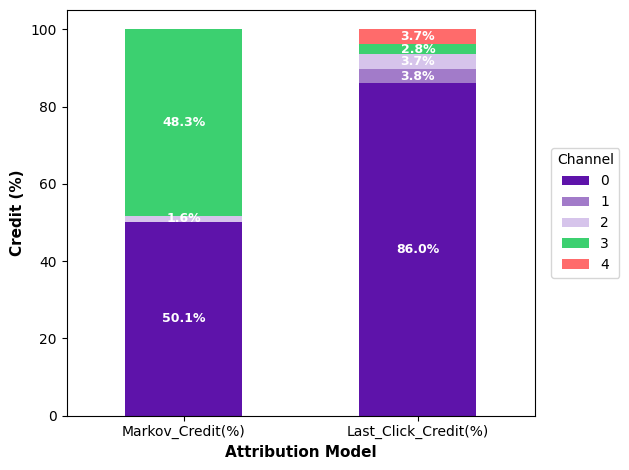

In [119]:
import matplotlib.pyplot as plt

colors = ["#5e13aa", "#a27bc9", "#d6c4eb", "#3cd070", "#ff6b6b"]

ax = B02_Last_click_Markov.plot(kind="bar", stacked=True, color=colors)

for container in ax.containers:
    labels = [f"{v.get_height():.1f}%" if v.get_height() > 0 else "" for v in container]
    ax.bar_label(container, labels=labels, label_type="center", color="white", fontsize=9, weight="bold")

plt.xlabel("Attribution Model", fontsize=11, weight="bold")
plt.ylabel("Credit (%)", fontsize=11, weight="bold")
plt.xticks(rotation=0)  
plt.legend(title="Channel", loc="center left", bbox_to_anchor=(1.02, 0.5))
plt.tight_layout()
plt.show()

In [120]:
build_transition_matrix('B01')

to_state,Conversion,Google Search,Influencer Blog,Instagram,Marketplace,Null,YouTube
from_state,,,,,,,
Google Search,0.007449,0.211809,0.131771,0.142064,0.124594,0.245395,0.136918
Influencer Blog,0.008296,0.135999,0.214198,0.137903,0.136815,0.243574,0.123215
Instagram,0.060287,0.120446,0.127886,0.209082,0.128143,0.220498,0.133658
Marketplace,0.007019,0.132122,0.132810,0.148225,0.195706,0.249931,0.134187
Start,0.000000,0.202712,0.195155,0.206233,0.199814,0.000000,0.196087
YouTube,0.007256,0.131846,0.131161,0.141566,0.135405,0.250685,0.202081


In [121]:
last_click_attr.head()

,Brand_ID,Last_Channel,Conversions,Last_Click_Credit
0,B01,Google Search,55,0.079710
1,B01,Influencer Blog,61,0.088406
2,B01,Instagram,470,0.681159
3,B01,Marketplace,51,0.073913
4,B01,YouTube,53,0.076812


In [122]:
last_click_attr1=last_click_attr.pivot(
    index = 'Brand_ID',
    columns='Last_Channel',
    values='Last_Click_Credit'
).round(2)
last_click_attr1

Last_Channel,Google Search,Influencer Blog,Instagram,Marketplace,YouTube
Brand_ID,,,,,
B01,0.08,0.09,0.68,0.07,0.08
B02,0.86,0.03,0.04,0.04,0.04
B03,0.22,0.23,0.19,0.17,0.19
B04,0.21,0.26,0.17,0.19,0.17
B05,0.24,0.24,0.22,0.27,0.03
B06,0.22,0.19,0.16,0.21,0.21
B07,0.69,0.02,0.02,0.24,0.02
B08,0.23,0.18,0.18,0.24,0.18
B09,0.05,0.02,0.04,0.84,0.05


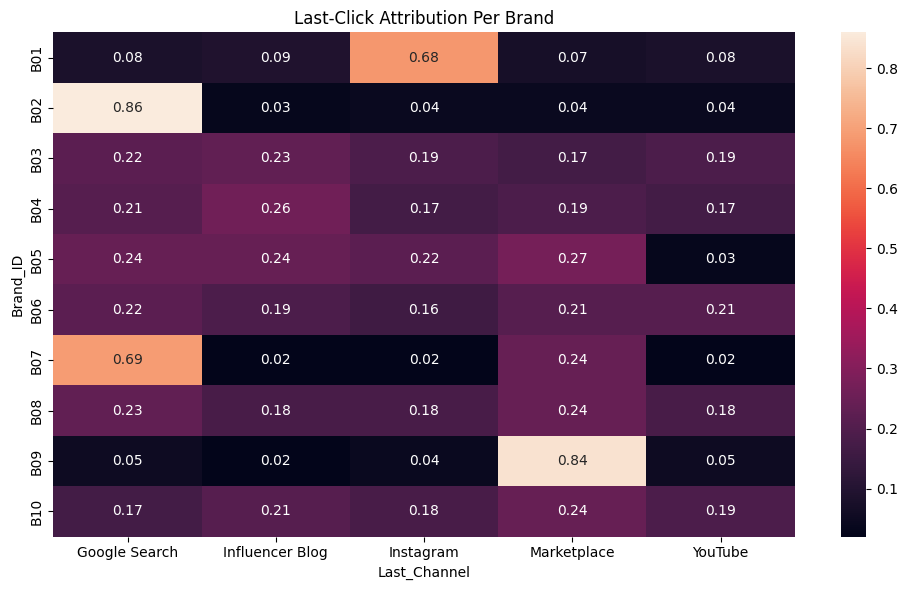

In [123]:
plt.figure(figsize=(10,6))
sns.heatmap(data=last_click_attr1,annot=True,fmt='.2f')
plt.title('Last-Click Attribution Per Brand')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('Last_Click_Attr_heatmap.png')
plt.show()

In [124]:
# Best vs Worst CPA

print('Best_CPA')
print()
print(cpa_df[cpa_df['CPA'] > 0][['Brand_ID','Channel','CPA']]
      .sort_values('CPA')
      .head(10))

print()
print('Worst_CPA')
print(cpa_df[cpa_df['CPA'] > 0][['Brand_ID','Channel','CPA']]
      .sort_values('CPA', ascending=False)
      .head(10))

Best_CPA

   Brand_ID          Channel           CPA
10      B01        Instagram    964.011276
31      B02  Influencer Blog   2555.054270
37      B08  Influencer Blog  11713.743220
6       B07    Google Search  16229.182395
39      B10  Influencer Blog  20733.159858
2       B03    Google Search  25618.450981
1       B02    Google Search  37085.992423
44      B05      Marketplace  42133.454878
49      B10      Marketplace  55734.880943
43      B04      Marketplace  57305.361095

Worst_CPA
   Brand_ID          Channel           CPA
20      B01          YouTube  1.246356e+07
12      B03        Instagram  3.925792e+06
38      B09  Influencer Blog  3.173314e+06
47      B08      Marketplace  2.160971e+06
28      B09          YouTube  1.905067e+06
21      B02          YouTube  1.126365e+06
5       B06    Google Search  3.430710e+05
30      B01  Influencer Blog  2.768313e+05
4       B05    Google Search  2.679073e+05
48      B09      Marketplace  2.517315e+05


In [125]:
#Budget
old_total = old_budget.sum()
new_total = reallocation_df.sum()
print(pd.DataFrame({'Old': old_total, 'New': new_total, 
                    'Change': new_total - old_total}))

                          Old           New        Change
Channel                                                  
Google Search    2.029821e+08  2.680793e+08  6.509724e+07
Influencer Blog  1.148977e+08  3.067600e+08  1.918623e+08
Instagram        1.941355e+08  1.053923e+08 -8.874323e+07
Marketplace      2.405746e+08  2.932113e+08  5.263663e+07
YouTube          2.660160e+08  2.655711e+07 -2.394589e+08


# ---------------------------------- Visulizations ----------------------------------

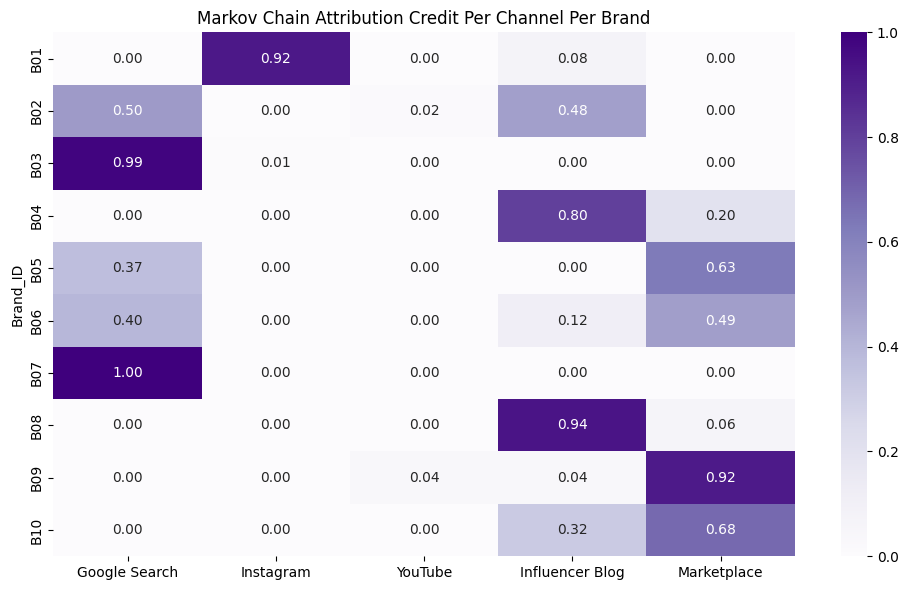

In [126]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(attribution_df, annot=True, fmt='.2f', cmap='Purples')
plt.title('Markov Chain Attribution Credit Per Channel Per Brand')
plt.tight_layout()
plt.savefig('attribution_heatmap.png')
plt.show()

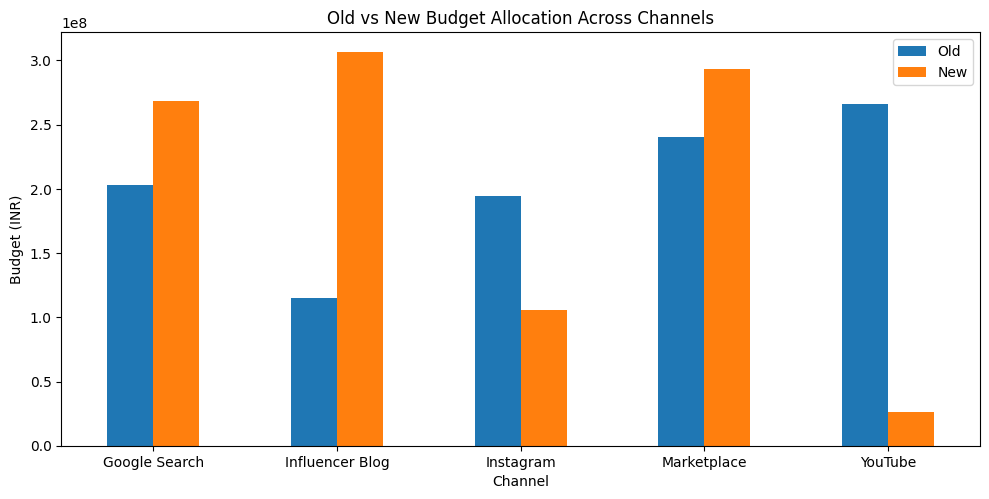

In [127]:
comparison = pd.DataFrame({
    'Old': old_budget.sum(),
    'New': reallocation_df.sum()
})

comparison.plot(kind='bar', figsize=(10,6))
plt.title('Old vs New Budget Allocation Across Channels')
plt.ylabel('Budget (INR)')
plt.tight_layout()
plt.xticks(rotation=0)
plt.savefig('budget_comparison.png')
plt.show()

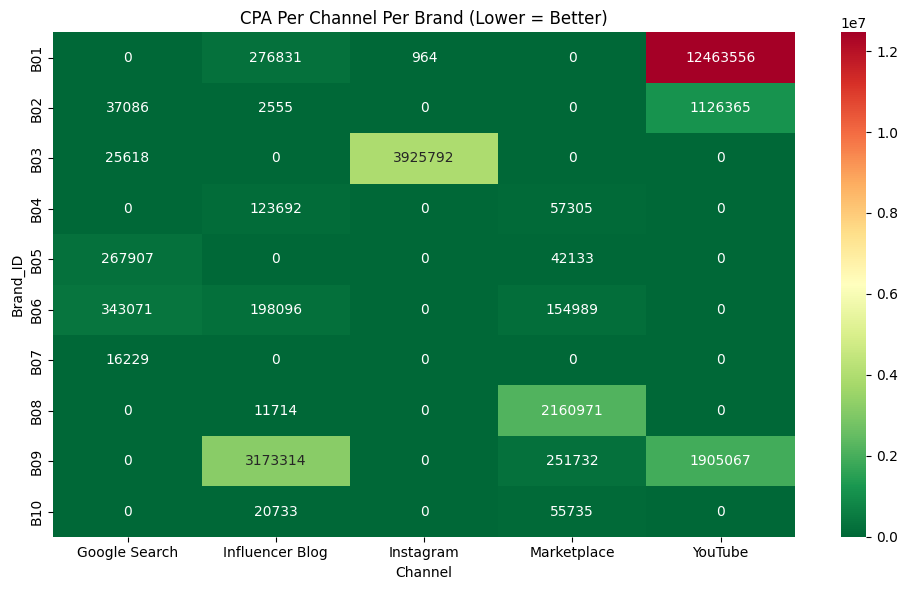

In [128]:
plt.figure(figsize=(10,6))
sns.heatmap(pivot_cpa, annot=True, fmt='.0f', 
            cmap='RdYlGn_r')
plt.title('CPA Per Channel Per Brand (Lower = Better)')
plt.tight_layout()
plt.savefig('cpa_heatmap.png')
plt.show()